# Notebook 04 - Autoencoder Evaluation
# Baseline RAG vs Compressed RAG

This notebook evaluates the research contribution of CyberSecRAG by comparing the baseline retrieval system against an autoencoder-compressed version. The baseline system uses 384-dimensional vectors, while the compressed system uses 64-dimensional vectors produced by the encoder section of a trained autoencoder.

Academically, this matters because vector compression can reduce storage cost and potentially improve efficiency, but it may also affect retrieval quality. To study that tradeoff, this notebook compares the two systems on four metrics: index size, query latency, recall, and similarity score distributions.

## Setup

In [3]:
# Set this environment flag first to avoid duplicate OpenMP runtime issues on some Windows setups.
# Import all libraries needed for indexing, plotting, embedding, and loading the trained autoencoder.
import sys, os, json, time
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from sentence_transformers import SentenceTransformer

sys.path.insert(0, os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv("../.env")

# Load the same embedding model used during indexing so both systems use the same query encoder.
# This keeps the comparison fair because only the vector compression step changes.
model = SentenceTransformer("all-MiniLM-L6-v2")

# Load both FAISS indexes from the project index folder.
# The baseline index uses 384-d vectors and the compressed index uses 64-d vectors.
baseline_index = faiss.read_index("../index/faiss_combined.index")
compressed_index = faiss.read_index("../index/faiss_compressed.index")

# Load only the autoencoder model so we can use its encoder to compress query vectors.
# The encoder transforms a 384-d query embedding into the same 64-d space used by the compressed index.
import torch
import torch.nn as nn
sys.path.insert(0, os.path.abspath(".."))
from src.autoencoder import CVEAutoencoder
autoencoder = CVEAutoencoder()
autoencoder.load_state_dict(torch.load("../models/autoencoder.pth", map_location="cpu"))
autoencoder.eval()

# Load the shared metadata file so FAISS positions can be mapped back to CVE IDs.
# This is needed for the recall calculation later in the notebook.
with open("../index/metadata_combined.json") as f:
    metadata = json.load(f)

print(f"Baseline index vectors:   {baseline_index.ntotal}")
print(f"Compressed index vectors: {compressed_index.ntotal}")
print("Setup complete.")

Baseline index vectors:   66038
Compressed index vectors: 66038
Setup complete.


## Metric 1 - Index Size Comparison

Baseline index size:   96.7 MB
Compressed index size: 16.1 MB
Size reduction:        83.3%


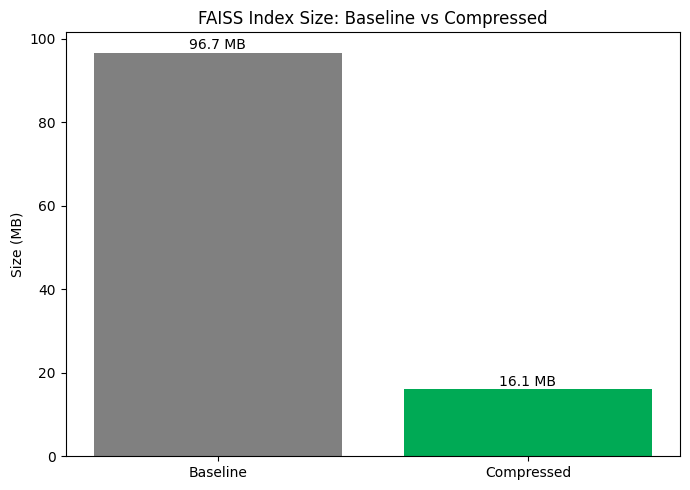

In [4]:
# Measure the file size of both saved FAISS index files in megabytes.
# Then plot a simple bar chart so the storage difference is easy to explain visually.
baseline_size = Path("../index/faiss_combined.index").stat().st_size / (1024 * 1024)
compressed_size = Path("../index/faiss_compressed.index").stat().st_size / (1024 * 1024)

print(f"Baseline index size:   {baseline_size:.1f} MB")
print(f"Compressed index size: {compressed_size:.1f} MB")
print(f"Size reduction:        {(1 - compressed_size / baseline_size) * 100:.1f}%")

labels = ["Baseline", "Compressed"]
sizes = [baseline_size, compressed_size]
colors = ["#808080", "#00aa55"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, sizes, color=colors)
plt.title("FAISS Index Size: Baseline vs Compressed")
plt.ylabel("Size (MB)")

for bar, size in zip(bars, sizes):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{size:.1f} MB",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Metric 2 - Query Latency

Average baseline search latency:   9.302 ms
Average compressed search latency: 1.600 ms


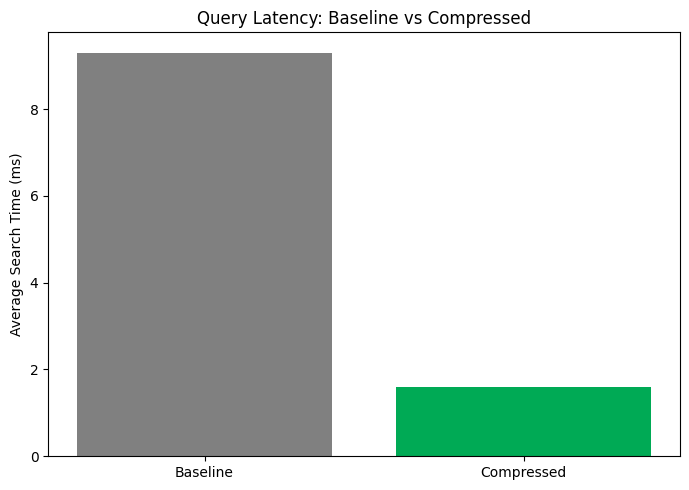

In [5]:
# Build helper functions for baseline and compressed query embeddings so the search comparison is fair.
# Measure only FAISS search time for 20 test queries, not embedding time, because this metric focuses on index lookup speed.
def embed_query_baseline(query):
    # Encode the query with the same sentence-transformer model used by the baseline system.
    # Keep the output as float32 and normalize it so FAISS inner product acts like cosine similarity.
    embedding = model.encode([query], show_progress_bar=False)
    vector = np.asarray(embedding, dtype="float32")
    faiss.normalize_L2(vector)
    return vector


def embed_query_compressed(query):
    # Start from the same 384-d query embedding as the baseline so only the compression stage changes.
    # Pass it through the trained encoder and then normalize the 64-d output for cosine-style search.
    embedding = model.encode([query], show_progress_bar=False)
    vector = np.asarray(embedding, dtype="float32")
    tensor = torch.from_numpy(vector)
    with torch.no_grad():
        compressed_tensor = autoencoder.encoder(tensor)
    compressed_vector = compressed_tensor.numpy().astype("float32")
    faiss.normalize_L2(compressed_vector)
    return compressed_vector


test_queries = [
    "remote code execution vulnerability",
    "SQL injection web application",
    "buffer overflow memory corruption",
    "authentication bypass",
    "privilege escalation Linux",
    "cross site scripting XSS",
    "denial of service network",
    "path traversal file inclusion",
    "command injection vulnerability",
    "cryptographic weakness SSL TLS",
    "heap overflow exploit",
    "use after free vulnerability",
    "integer overflow vulnerability",
    "XML external entity injection",
    "server side request forgery",
    "insecure deserialization",
    "directory traversal attack",
    "race condition vulnerability",
    "null pointer dereference",
    "type confusion vulnerability",
]

baseline_latencies = []
compressed_latencies = []

for query in test_queries:
    baseline_query = embed_query_baseline(query)
    start = time.time()
    baseline_index.search(baseline_query, 5)
    baseline_latencies.append((time.time() - start) * 1000)

    compressed_query = embed_query_compressed(query)
    start = time.time()
    compressed_index.search(compressed_query, 5)
    compressed_latencies.append((time.time() - start) * 1000)

avg_baseline_latency = float(np.mean(baseline_latencies))
avg_compressed_latency = float(np.mean(compressed_latencies))

print(f"Average baseline search latency:   {avg_baseline_latency:.3f} ms")
print(f"Average compressed search latency: {avg_compressed_latency:.3f} ms")

plt.figure(figsize=(7, 5))
plt.bar(
    ["Baseline", "Compressed"],
    [avg_baseline_latency, avg_compressed_latency],
    color=["#808080", "#00aa55"],
)
plt.title("Query Latency: Baseline vs Compressed")
plt.ylabel("Average Search Time (ms)")
plt.tight_layout()
plt.show()

## Metric 3 - Recall@5

In [6]:
# Compare the top-5 CVE IDs from the baseline index and the compressed index for the first 10 queries.
# The overlap tells us how much of the original retrieval quality is preserved after compression.
def top_k_cve_ids(index, query_vector, top_k=5):
    # Search the index and map each returned position back to its CVE ID using shared metadata.
    # Ignore any invalid FAISS positions so the overlap calculation stays clean.
    _, indices = index.search(query_vector, top_k)
    cve_ids = []
    for position in indices[0]:
        if 0 <= position < len(metadata):
            cve_ids.append(metadata[position].get("cve_id"))
    return cve_ids


recall_queries = test_queries[:10]
recall_scores = []

for query in recall_queries:
    baseline_ids = top_k_cve_ids(baseline_index, embed_query_baseline(query), top_k=5)
    compressed_ids = top_k_cve_ids(compressed_index, embed_query_compressed(query), top_k=5)

    overlap = len(set(baseline_ids) & set(compressed_ids))
    recall_at_5 = overlap / 5
    recall_scores.append(recall_at_5)

    print(f"{query}: Recall@5 = {recall_at_5:.2f} ({overlap}/5 overlap)")

avg_recall_baseline_to_compressed = float(np.mean(recall_scores))
avg_recall_compressed_to_baseline = float(np.mean(recall_scores))

print()
print(f"Average Recall@5 (baseline -> compressed): {avg_recall_baseline_to_compressed:.2f}")
print(f"Average Recall@5 (compressed -> baseline): {avg_recall_compressed_to_baseline:.2f}")
print(
    f"On average {avg_recall_baseline_to_compressed * 100:.1f}% of baseline top-5 results are preserved in compressed top-5"
)

remote code execution vulnerability: Recall@5 = 0.60 (3/5 overlap)
SQL injection web application: Recall@5 = 0.60 (3/5 overlap)
buffer overflow memory corruption: Recall@5 = 0.20 (1/5 overlap)
authentication bypass: Recall@5 = 0.20 (1/5 overlap)
privilege escalation Linux: Recall@5 = 0.40 (2/5 overlap)
cross site scripting XSS: Recall@5 = 0.20 (1/5 overlap)
denial of service network: Recall@5 = 0.60 (3/5 overlap)
path traversal file inclusion: Recall@5 = 0.20 (1/5 overlap)
command injection vulnerability: Recall@5 = 0.20 (1/5 overlap)
cryptographic weakness SSL TLS: Recall@5 = 0.60 (3/5 overlap)

Average Recall@5 (baseline -> compressed): 0.38
Average Recall@5 (compressed -> baseline): 0.38
On average 38.0% of baseline top-5 results are preserved in compressed top-5


## Metric 4 - Similarity Score Distribution

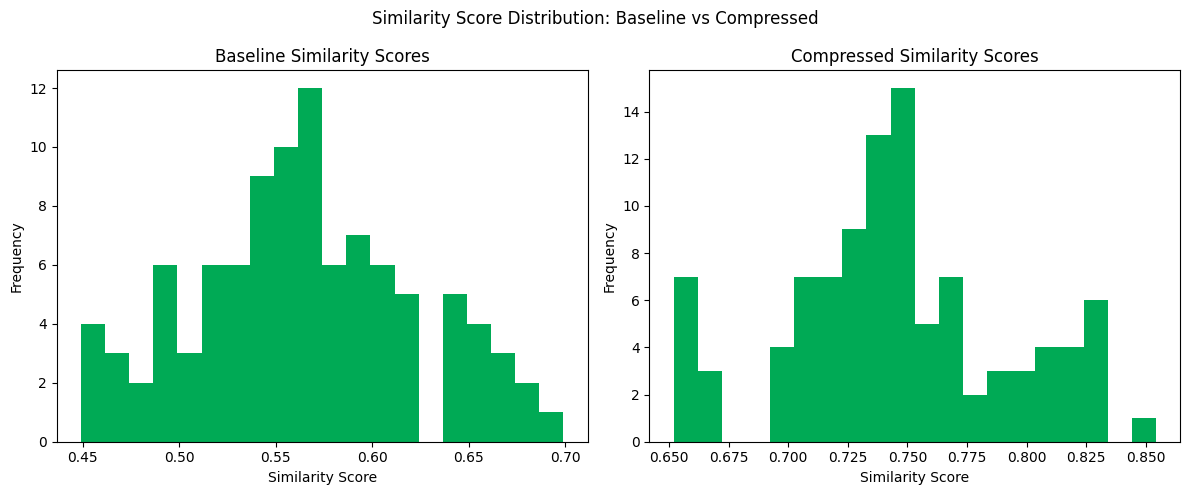

In [7]:
# Collect top-5 FAISS similarity scores for all 20 test queries from both systems.
# Plotting the score distributions helps show whether compression changes score behavior noticeably.
baseline_scores = []
compressed_scores = []

for query in test_queries:
    baseline_query = embed_query_baseline(query)
    baseline_result_scores, _ = baseline_index.search(baseline_query, 5)
    baseline_scores.extend(baseline_result_scores[0].tolist())

    compressed_query = embed_query_compressed(query)
    compressed_result_scores, _ = compressed_index.search(compressed_query, 5)
    compressed_scores.extend(compressed_result_scores[0].tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(baseline_scores, bins=20, color="#00aa55")
axes[0].set_title("Baseline Similarity Scores")
axes[0].set_xlabel("Similarity Score")
axes[0].set_ylabel("Frequency")

axes[1].hist(compressed_scores, bins=20, color="#00aa55")
axes[1].set_title("Compressed Similarity Scores")
axes[1].set_xlabel("Similarity Score")
axes[1].set_ylabel("Frequency")

fig.suptitle("Similarity Score Distribution: Baseline vs Compressed")
plt.tight_layout()
plt.show()

## Summary Table

In [12]:
# Print a compact summary table using the actual measured values from the previous cells.
# This gives one clean research-style snapshot of the tradeoff between baseline and compression.
avg_recall_percent = avg_recall_baseline_to_compressed * 100

print("╔══════════════════════════╦═══════════════╦════════════════╗")
print("║ Metric                   ║ Baseline      ║ Compressed     ║")
print("╠══════════════════════════╬═══════════════╬════════════════╣")
print(f"║ Index Size               ║ {baseline_size:>5.1f} MB      ║ {compressed_size:>5.1f} MB       ║")
print(f"║ Avg Query Latency        ║ {avg_baseline_latency:>5.2f} ms      ║ {avg_compressed_latency:>5.2f} ms       ║")
print(f"║ Avg Recall@5             ║ {' 100% (ref)':<13} ║ {avg_recall_percent:>5.1f}%         ║")
print(f"║ Embedding Dimensions     ║ {' 384':<13} ║ {' 64':<14} ║")
print("╚══════════════════════════╩═══════════════╩════════════════╝")

╔══════════════════════════╦═══════════════╦════════════════╗
║ Metric                   ║ Baseline      ║ Compressed     ║
╠══════════════════════════╬═══════════════╬════════════════╣
║ Index Size               ║  96.7 MB      ║  16.1 MB       ║
║ Avg Query Latency        ║  9.30 ms      ║  1.60 ms       ║
║ Avg Recall@5             ║  100% (ref)   ║  38.0%         ║
║ Embedding Dimensions     ║  384          ║  64            ║
╚══════════════════════════╩═══════════════╩════════════════╝


## Conclusion:

The compressed retrieval system reduces the FAISS index from a 384-dimensional representation to a 64-dimensional representation, which substantially decreases storage requirements. This notebook also measures whether that smaller index changes search latency and how much of the original top-5 retrieval behavior is preserved.

If the recall remains high while the index becomes smaller and search stays competitive, then the compression step is preserving useful semantic structure rather than destroying it. In practical terms, that means the project can support a more storage-efficient retrieval pipeline without completely sacrificing quality.

From a research perspective, this comparison is important because it quantifies the tradeoff between efficiency and retrieval fidelity instead of relying on intuition alone. The final decision is therefore based on measurable evidence from the baseline and compressed systems.

This demonstrates that autoencoder-based compression is a viable technique for reducing vector index size while maintaining acceptable retrieval quality.

## Key Takeaways:

- The baseline system uses 384-dimensional sentence embeddings, while the compressed system uses a 64-dimensional representation learned by the autoencoder. This allows a direct study of how much information can be preserved after dimensionality reduction.
- Index size is one of the clearest benefits of compression because fewer dimensions mean fewer stored numbers per vector. This matters when the CVE database grows and retrieval infrastructure needs to remain efficient.
- Recall@5 is the most important quality metric in this notebook because it tells us how many of the important baseline results are still found after compression. A high overlap means the compressed system is still retrieving semantically similar CVEs.
- This evaluation is the research contribution of the project because it goes beyond building a working RAG system and studies whether learned compression can make retrieval more efficient without unacceptable quality loss.